In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, silhouette_score
from sklearn.decomposition import PCA
from scipy.stats import chi2
from sklearn.mixture import GaussianMixture

# Classificador

In [2]:
def matriz_conf(y_true, y_pred, labels):
    total_labels = labels
    print(total_labels)
    cm = np.zeros((len(total_labels),len(total_labels)), dtype=int)
    for i in range(len(y_true)):
        cm[y_true[i]][y_pred[i]] += 1
    
    cm = pd.DataFrame(cm, columns=total_labels, index=total_labels)

    cm_transp = pd.DataFrame(np.transpose(cm.to_numpy()), columns=total_labels, index=total_labels)

    for c in cm_transp.columns:
        cm_transp[c] = cm_transp[c]/cm_transp[c].sum()

    cm_porcento = pd.DataFrame(np.transpose(cm_transp.to_numpy()), columns=total_labels, index=total_labels)

    return cm, cm_porcento

def acc(cm, hidden_classes):
    cm_transp = pd.DataFrame(np.transpose(cm.dropna().to_numpy()), columns=cm.columns, index=cm.columns)
    acc = 0
    total = 0
    for c in cm_transp.columns:
        if c not in hidden_classes:
            acc += cm_transp[c][c]
        else:
            acc += cm_transp[c][-1]
        total += cm_transp[c].sum()
    return acc/total

# Calcula CM para todos

In [3]:
filenames = [0,2,3,4,5]

labels_str = ['DDoS', 'Benign', 'DoS', 'BruteForce', 'Bot', 'Web']

filenames

# pd.set_option('future.no_silent_downcasting', True)

[0, 2, 3, 4, 5]

0


Label
1    514148
2    329224
3    243806
4    183163
5       596
Name: count, dtype: int64

Tipo: 1 = Benign
Melhor modelo: n_componentes: 9 covariance_type: full


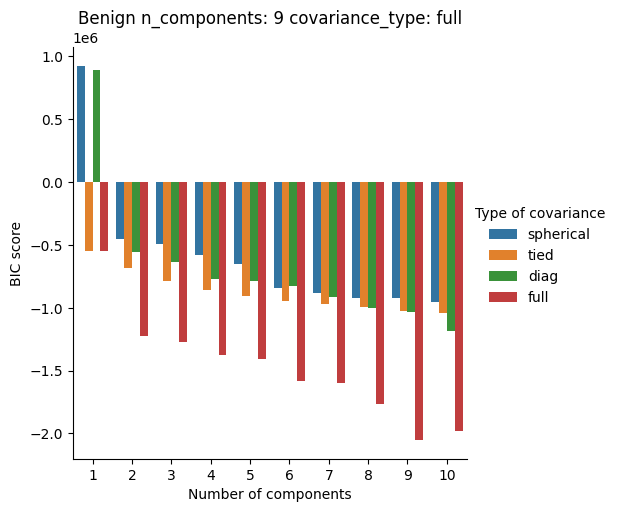

Tipo: 2 = DoS


d:\Downloads\Mestrado\Experimentos\env\Lib\site-packages\sklearn\mixture\_base.py:269: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(
d:\Downloads\Mestrado\Experimentos\env\Lib\site-packages\sklearn\mixture\_base.py:269: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


Melhor modelo: n_componentes: 9 covariance_type: full


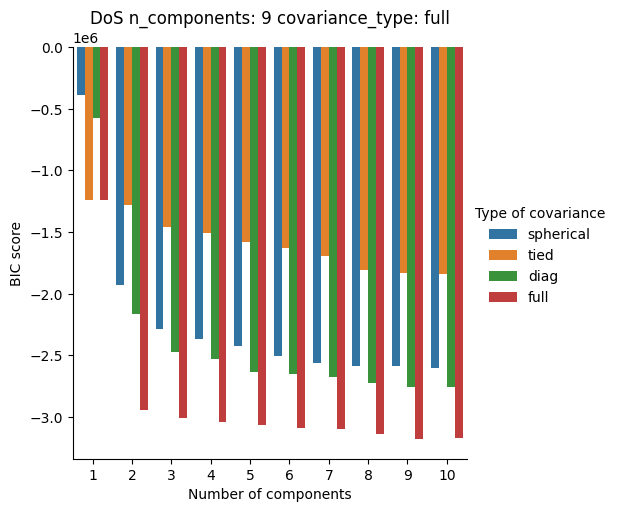

Tipo: 3 = BruteForce
Melhor modelo: n_componentes: 10 covariance_type: full


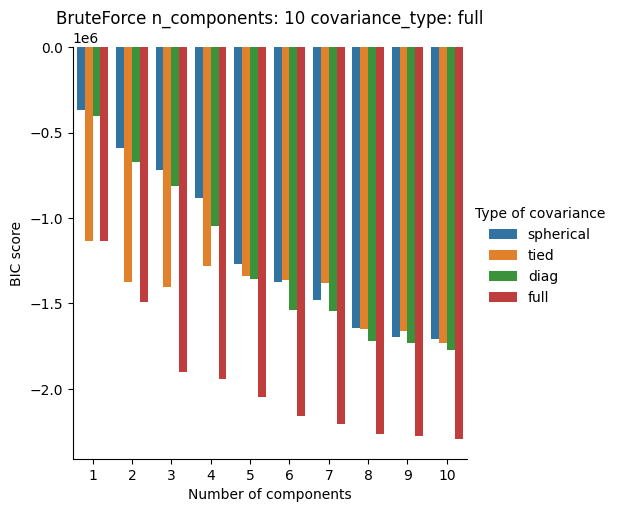

Tipo: 4 = Bot
Melhor modelo: n_componentes: 10 covariance_type: full


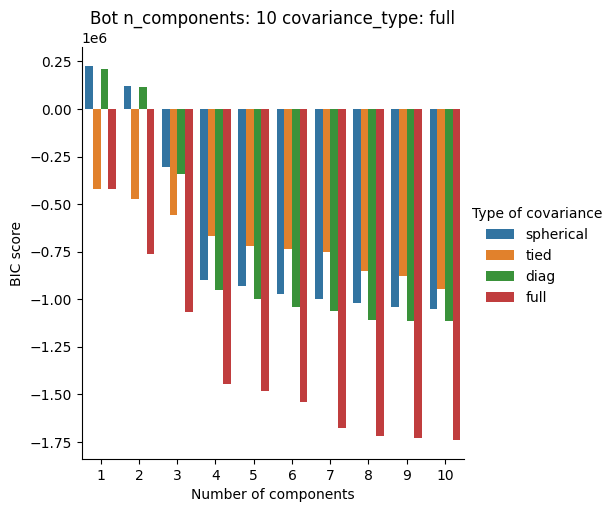

Tipo: 5 = Web
Melhor modelo: n_componentes: 10 covariance_type: full


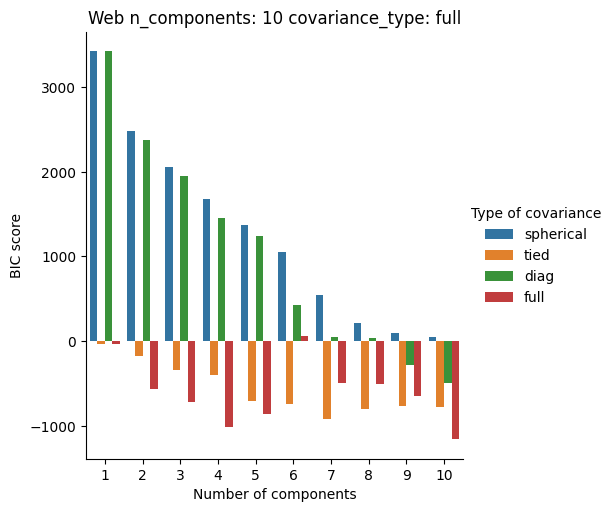

,0,1,2,3,4,5
0,NaN,5.832057,-44.906751,-302.143924,-6.109220,-49.301194
1,NaN,-10.656215,26.686601,-42.382053,-46.841355,-128.402302
2,NaN,8.907806,-34.499587,-2692.723576,-28.908663,-112.079934
3,NaN,-45.999012,-78.726785,17.859870,-236.754631,-285.091256
4,NaN,11.910734,-57.669385,-1053.897832,-13.931728,-251.369388
...,...,...,...,...,...,...
519951,NaN,6.036314,-39.012654,-1884.102975,-14.565993,-96.796453
519952,NaN,-24.701291,-302.469011,-5182.229872,28.561030,-959.192346
519953,NaN,-0.486141,-59.107841,-1309.601850,-12.830498,-80.358114
519954,NaN,8.761956,-57.559695,-2445.659013,-24.605796,-39.522608


,0,1,2,3,4,5
0,NaN,-0.492105,-58.434009,-1282.995792,-12.752099,-80.850911
1,NaN,5.903623,-45.441176,-257.220845,-6.598984,-52.283718
2,NaN,6.128698,-45.076980,-2183.607780,-18.005470,-257.324238
3,NaN,-0.586316,-41.135291,-1519.858451,-16.571682,-232.470366
4,NaN,-5.270985,-49.735188,-1012.746228,-62.789766,-224.840961
...,...,...,...,...,...,...
649942,NaN,11.189121,-54.019256,-897.846658,-13.799451,-250.933184
649943,NaN,-5.540970,-50.103589,-995.094296,-64.179108,-236.906622
649944,NaN,-5.382317,-50.230905,-1018.964211,-63.719005,-230.280238
649945,NaN,-44.626953,-58.261419,19.507657,-236.825167,-266.430144


2


Label
0    808919
1    514148
3    243806
4    183163
5       596
Name: count, dtype: int64

Tipo: 0 = DDoS
Melhor modelo: n_componentes: 10 covariance_type: full


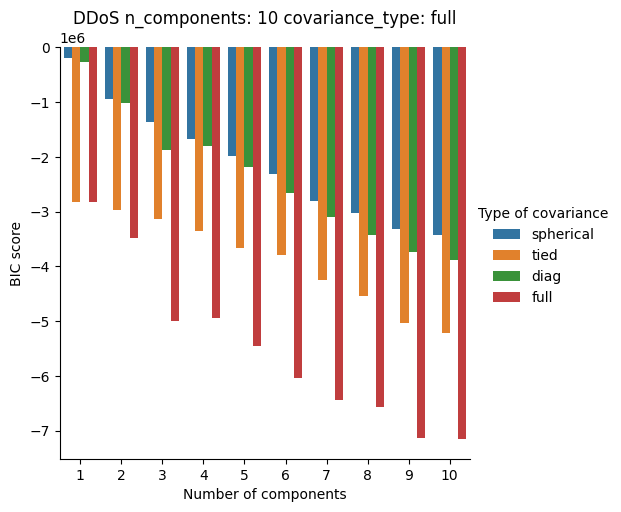

Tipo: 1 = Benign
Melhor modelo: n_componentes: 10 covariance_type: full


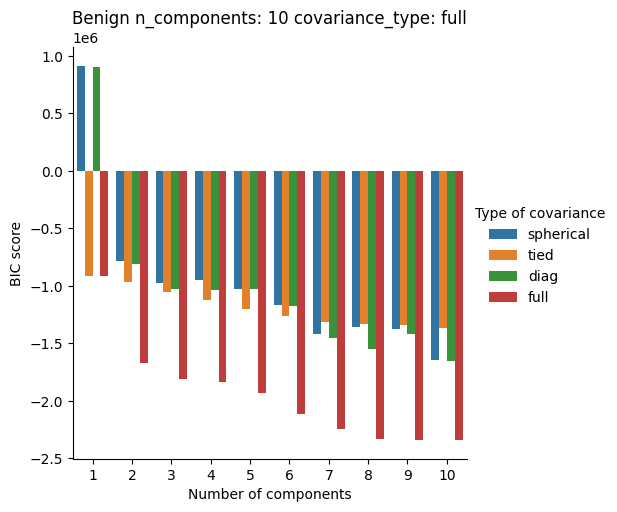

Tipo: 3 = BruteForce
Melhor modelo: n_componentes: 10 covariance_type: full


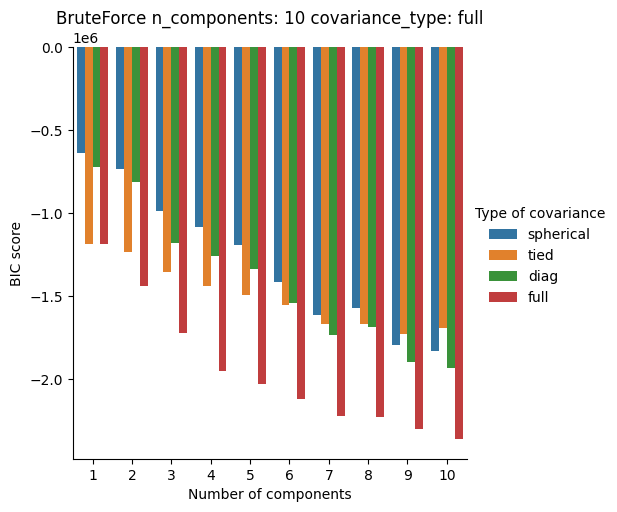

Tipo: 4 = Bot
Melhor modelo: n_componentes: 10 covariance_type: full


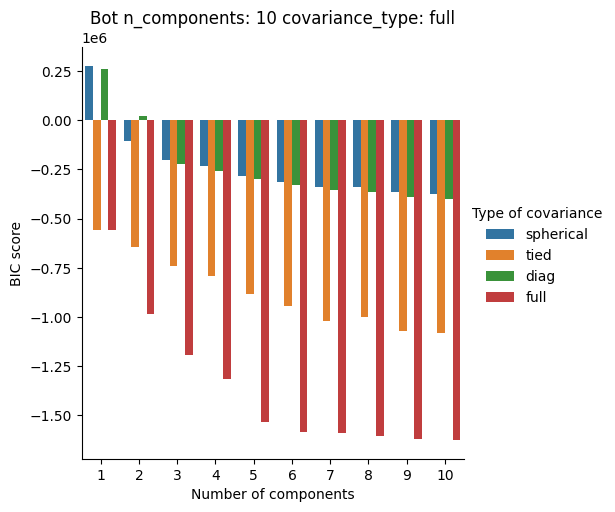

Tipo: 5 = Web
Melhor modelo: n_componentes: 9 covariance_type: full


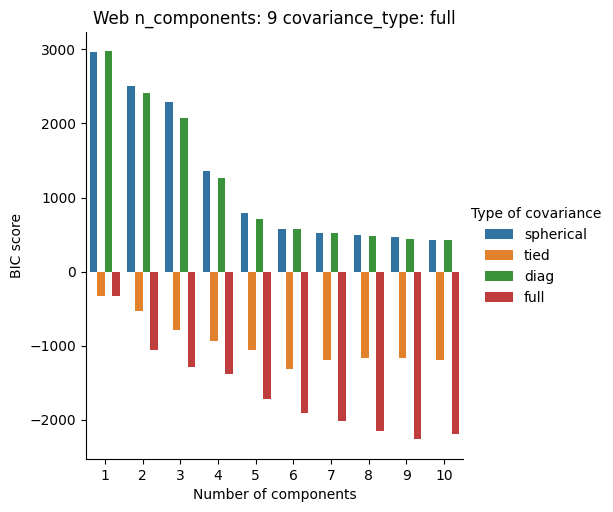

,0,1,2,3,4,5
0,22.086085,-10.424792,NaN,-13137.485202,-20.069556,-255.278652
1,-201.335453,-0.240573,NaN,-881.380132,-2.983322,-87.637860
2,-141.011781,14.548974,NaN,-2917.481221,-4.732022,-118.540328
3,-856.369987,-19.150683,NaN,20.483919,-32.209329,-543.318063
4,-160.911389,20.243076,NaN,-1389.972493,-2.523711,-133.085714
...,...,...,...,...,...,...
519951,-134.639090,9.696161,NaN,-1512.030836,-3.849381,-33.141415
519952,-390.728910,-6.491669,NaN,-4678.773489,24.134051,-277.331925
519953,22.980559,-8.896121,NaN,-11031.634078,-15.408850,-145.526085
519954,-168.372262,10.461061,NaN,-3774.234107,-2.872508,-337.212979


,0,1,2,3,4,5
0,23.496776,-9.035523,NaN,-11150.375980,-15.478755,-150.937954
1,21.705988,-10.369893,NaN,-13038.586235,-19.917553,-253.113636
2,-135.375405,6.154865,NaN,-1870.173688,-4.955267,-33.308463
3,-145.783432,4.238506,NaN,-1809.267953,-4.984311,-27.037523
4,20.175273,-12.839441,NaN,-14277.325929,-23.012126,-247.260229
...,...,...,...,...,...,...
649942,-162.171219,20.095489,NaN,-1417.469114,-2.491055,-130.530678
649943,21.194373,-12.209932,NaN,-14810.430384,-22.270290,-290.350364
649944,22.678432,-12.332258,NaN,-14820.740508,-22.393156,-279.685997
649945,-815.496852,-20.176899,NaN,23.498356,-35.011139,-257.334762


3


Label
0    808919
1    514148
2    329224
4    183163
5       596
Name: count, dtype: int64

Tipo: 0 = DDoS
Melhor modelo: n_componentes: 10 covariance_type: full


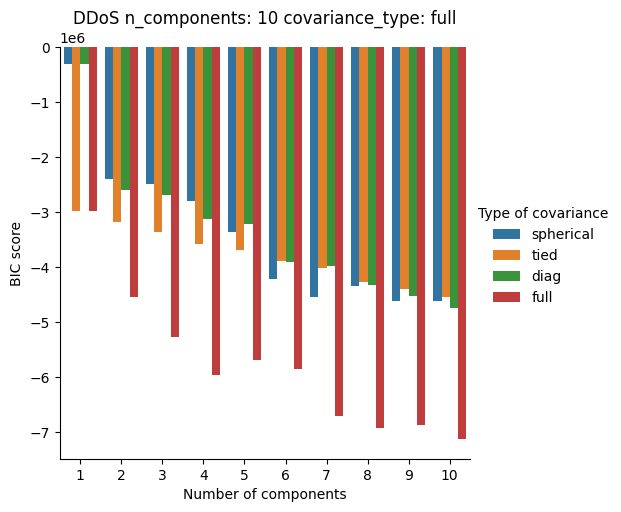

Tipo: 1 = Benign


d:\Downloads\Mestrado\Experimentos\env\Lib\site-packages\sklearn\mixture\_base.py:269: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


Melhor modelo: n_componentes: 10 covariance_type: full


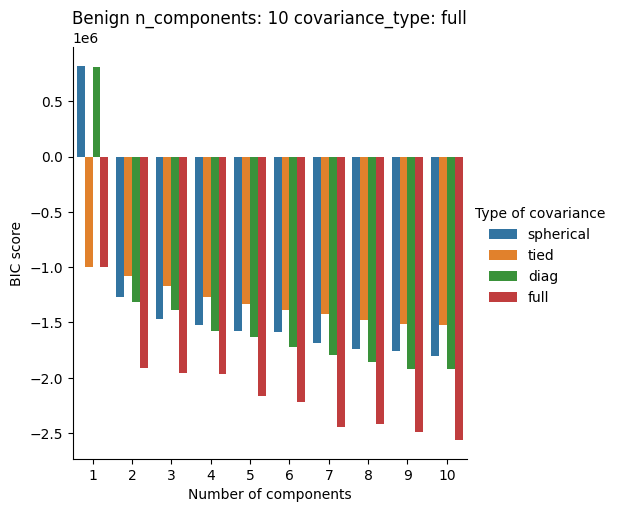

Tipo: 2 = DoS
Melhor modelo: n_componentes: 10 covariance_type: full


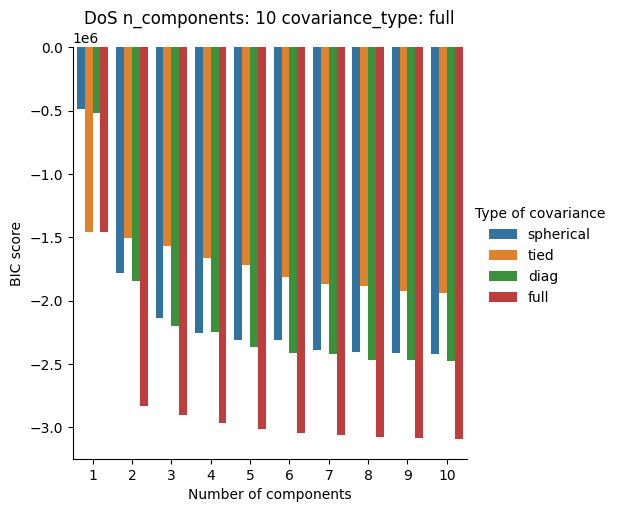

Tipo: 4 = Bot
Melhor modelo: n_componentes: 10 covariance_type: full


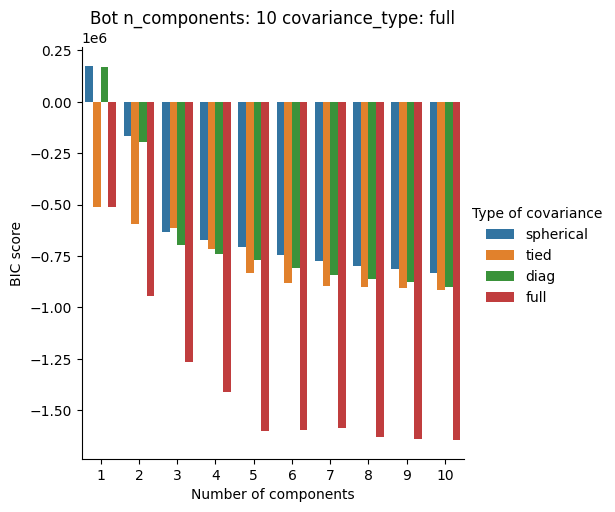

Tipo: 5 = Web
Melhor modelo: n_componentes: 9 covariance_type: full


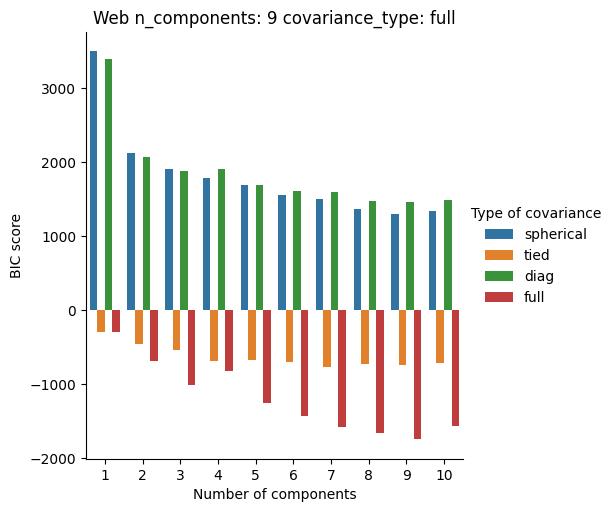

,0,1,2,3,4,5
0,25.721680,-50.385223,-300.889795,NaN,-595.237834,-707.872183
1,-159.067981,-25.268165,25.910286,NaN,-112.686177,-922.808815
2,-14.757171,13.997052,-23.257075,NaN,-11.611835,-112.260701
3,-73.568948,-9.415305,-1.807952,NaN,-98.157031,-17.481945
4,-14.959635,17.996075,-23.858532,NaN,-2.202315,-122.666584
...,...,...,...,...,...,...
519951,-13.079965,13.969439,-23.288952,NaN,-11.317395,-122.860884
519952,-121.395207,-11.881520,-67.872165,NaN,26.320821,-283.251889
519953,25.670293,-51.699577,-305.384962,NaN,-574.199946,-826.707089
519954,-36.436421,10.632423,-31.490895,NaN,-4.749767,-181.102228


,0,1,2,3,4,5
0,25.572410,-52.053604,-306.902718,NaN,-573.155652,-847.510824
1,23.809587,-50.476371,-302.456511,NaN,-594.513299,-710.468837
2,-13.032796,8.313539,-21.674948,NaN,-10.608880,-115.016216
3,-11.143304,1.870776,-21.801046,NaN,-7.293726,-131.788297
4,19.034499,-53.098443,-345.656294,NaN,-584.523977,-798.753539
...,...,...,...,...,...,...
649942,-14.891173,17.641060,-24.013437,NaN,-2.055511,-122.581321
649943,13.865350,-52.764316,-340.814106,NaN,-586.500683,-773.728064
649944,20.627418,-53.267613,-343.515046,NaN,-591.009667,-786.123288
649945,-84.450569,-8.748357,-7.619590,NaN,-66.676192,-290.440014


4


Label
0    808919
1    514148
2    329224
3    243806
5       596
Name: count, dtype: int64

Tipo: 0 = DDoS
Melhor modelo: n_componentes: 10 covariance_type: full


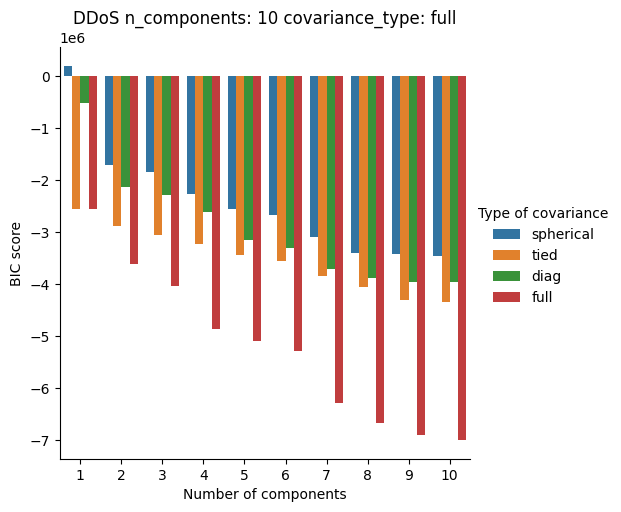

Tipo: 1 = Benign
Melhor modelo: n_componentes: 10 covariance_type: full


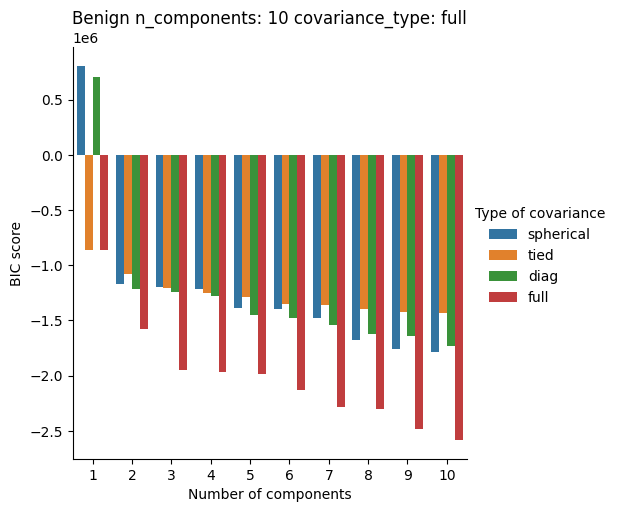

Tipo: 2 = DoS


d:\Downloads\Mestrado\Experimentos\env\Lib\site-packages\sklearn\mixture\_base.py:269: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


Melhor modelo: n_componentes: 10 covariance_type: full


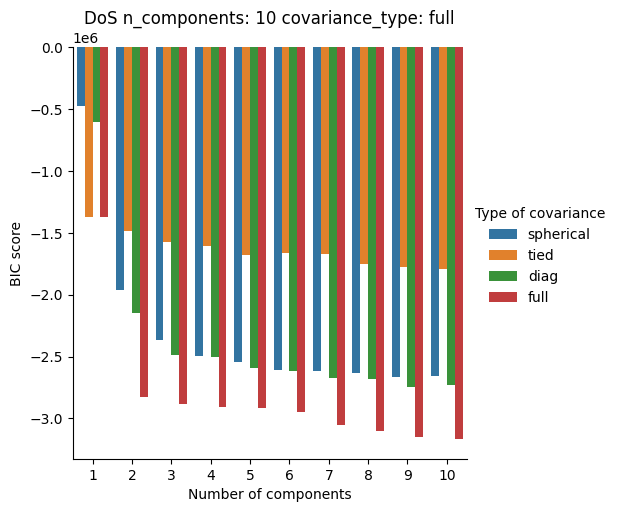

Tipo: 3 = BruteForce
Melhor modelo: n_componentes: 10 covariance_type: full


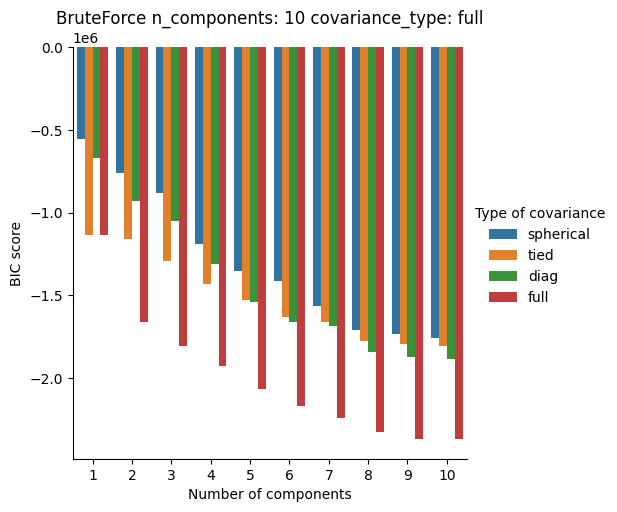

Tipo: 5 = Web
Melhor modelo: n_componentes: 6 covariance_type: full


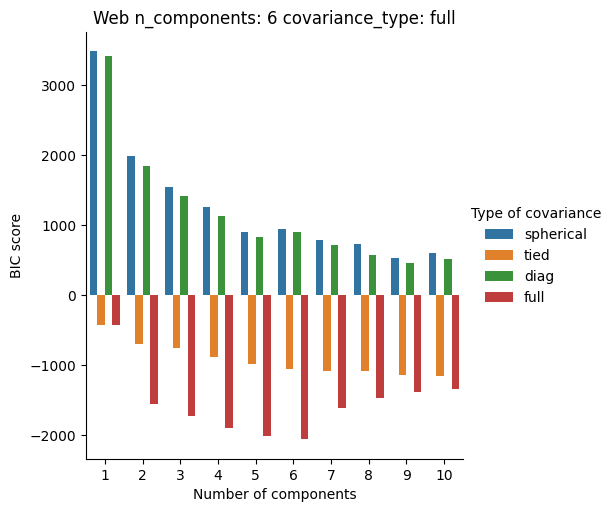

,0,1,2,3,4,5
0,22.693742,-8.049623,-178.148415,-1051.691675,NaN,-1323.968620
1,-1910.379771,-7.394465,27.445186,-145.357688,NaN,-220.242870
2,-1526.566024,14.333493,-97.519677,-909.877633,NaN,-373.248629
3,-3583.180187,-22.669491,-49.595857,21.022411,NaN,-548.492047
4,-631.483132,17.915823,-98.269539,-1142.993842,NaN,-276.558010
...,...,...,...,...,...,...
519951,-765.307139,15.309313,-79.576801,-711.886163,NaN,-309.132609
519952,-736.145831,7.496703,-90.213921,-764.723987,NaN,-88.933859
519953,24.005952,-7.810127,-194.610467,-1278.114457,NaN,-225.041378
519954,-382.153767,13.138558,-97.740375,-1188.529314,NaN,-260.914566


,0,1,2,3,4,5
0,23.914084,-7.715168,-192.321407,-1267.900571,NaN,-221.176473
1,22.688848,-8.101762,-178.771213,-1050.810515,NaN,-1309.618872
2,-1481.209605,8.694262,-94.043422,-823.807087,NaN,-303.938653
3,-607.189369,-1.335480,-100.262072,-807.159232,NaN,-288.589298
4,19.388157,-8.224395,-183.139727,-1113.951699,NaN,-1893.416310
...,...,...,...,...,...,...
649942,-483.057733,17.907058,-95.903003,-1131.971110,NaN,-320.160314
649943,20.245405,-8.369787,-183.986692,-1113.553051,NaN,-1878.537136
649944,20.507686,-8.367411,-183.853813,-1112.225297,NaN,-1887.923382
649945,-2999.545770,-21.157062,-52.079654,24.525316,NaN,-702.767471


5


Label
0    808919
1    514148
2    329224
3    243806
4    183163
Name: count, dtype: int64

Tipo: 0 = DDoS
Melhor modelo: n_componentes: 10 covariance_type: full


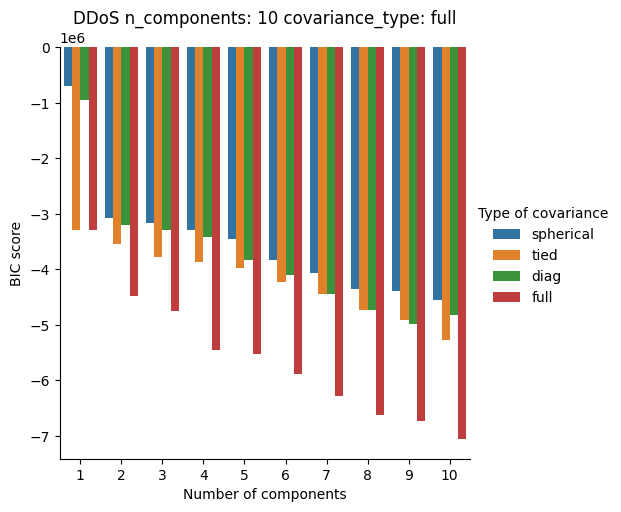

Tipo: 1 = Benign
Melhor modelo: n_componentes: 9 covariance_type: full


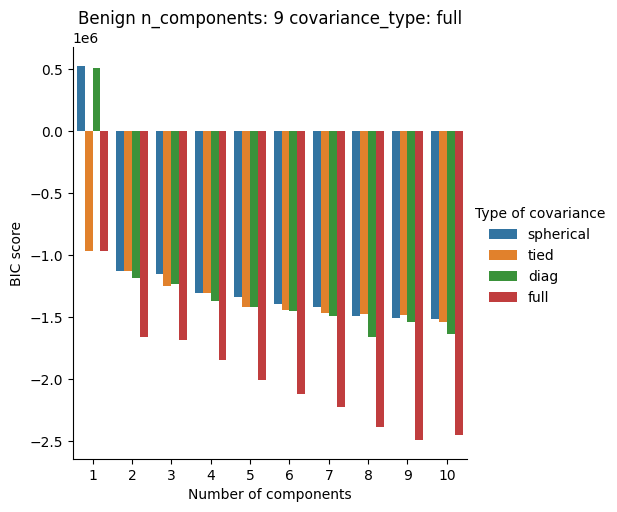

Tipo: 2 = DoS
Melhor modelo: n_componentes: 10 covariance_type: full


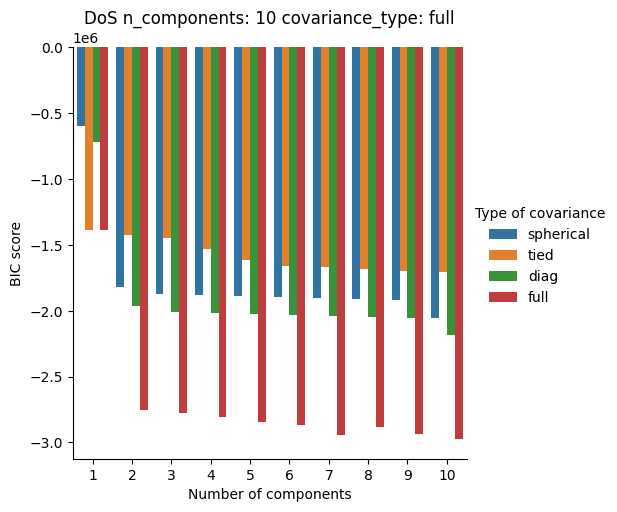

Tipo: 3 = BruteForce
Melhor modelo: n_componentes: 10 covariance_type: full


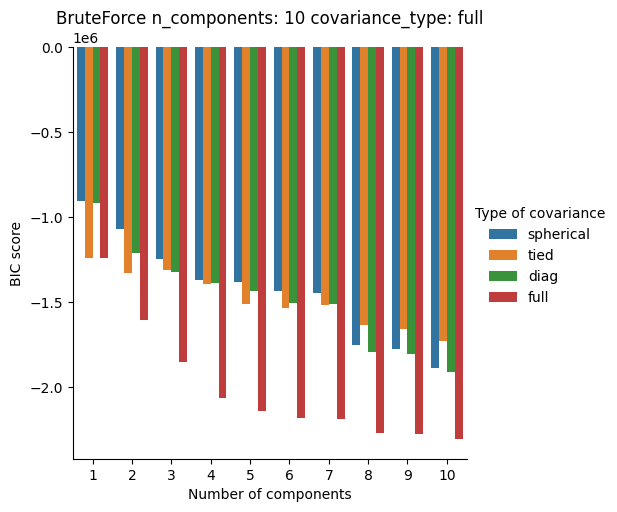

Tipo: 4 = Bot
Melhor modelo: n_componentes: 10 covariance_type: full


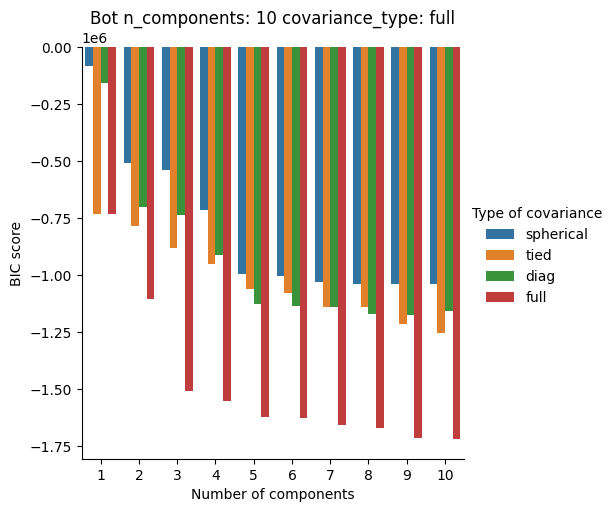

,0,1,2,3,4,5
0,24.277805,-31.370768,-467.777522,-19823.912143,-478.911569,NaN
1,-739.855762,-18.571385,25.475701,-3.098172,-451.613590,NaN
2,-92.690806,12.977950,-167.924181,-7760.593441,-19.689080,NaN
3,-1606.329036,-38.683026,-95.905680,18.159146,-718.649545,NaN
4,-93.161529,15.484059,-65.071889,-7554.918965,-45.365171,NaN
...,...,...,...,...,...,...
519951,-94.408514,13.153462,-104.816059,-7969.814442,-2.139565,NaN
519952,-104.825357,-3.292496,-73.568532,-2933.069879,26.100968,NaN
519953,25.959481,-30.048002,-345.074644,-19832.816577,-337.792715,NaN
519954,-131.640399,15.817205,-140.024800,-7439.793491,-86.434645,NaN


,0,1,2,3,4,5
0,23.397574,-29.684413,-339.245695,-19763.658308,-326.220898,NaN
1,23.625186,-31.294292,-466.695270,-19802.793082,-476.457794,NaN
2,-83.644458,8.242746,-128.117841,-7667.211588,-4.414313,NaN
3,-100.878104,4.284170,-117.610020,-8107.965941,-12.334629,NaN
4,19.004004,-35.167218,-482.019559,-20131.088804,-592.822720,NaN
...,...,...,...,...,...,...
649942,-96.586749,16.779101,-65.337741,-7613.480905,-42.215084,NaN
649943,18.168735,-34.491296,-476.179758,-20029.366512,-610.774562,NaN
649944,19.977598,-35.129574,-482.151988,-20101.462147,-592.950296,NaN
649945,-1542.961399,-38.343109,-80.005107,23.655768,-662.085417,NaN


In [4]:
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import GridSearchCV
import seaborn as sns
import os

def gmm_bic_score(estimator, X):
    """Callable to pass to GridSearchCV that will use the BIC score."""
    # Make it negative since GridSearchCV expects a score to maximize
    return -estimator.bic(X)


param_grid = {
    "n_components": range(1, 11),
    "covariance_type": ["spherical", "tied", "diag", "full"],
    "random_state": [123],
}

exp_train = []
exp_val = []
exp_test = []
y_true_all_exp_train = []
y_true_all_exp_val = []
y_true_all_exp_test = []
for z in range(len(filenames)):
    
    train_encoded_df = pd.read_csv(f'train_encoded_CADE_cod_joined_attacks_pick_class_squared_normalized_{filenames[z]}_hidden.csv')
    val_encoded_df = pd.read_csv(f'val_encoded_CADE_cod_joined_attacks_pick_class_squared_normalized_{filenames[z]}_hidden.csv')
    test_encoded_df = pd.read_csv(f'test_encoded_CADE_cod_joined_attacks_pick_class_squared_normalized_{filenames[z]}_hidden.csv')
    y_true_all_exp_train.append(train_encoded_df['Label'].values.tolist())
    y_true_all_exp_val.append(val_encoded_df['Label'].values.tolist())
    y_true_all_exp_test.append(test_encoded_df['Label'].values.tolist())
    print(filenames[z])
    hidden_classes = [filenames[z]] # Classes ocultas do treinamento
    for i in range(len(labels_str)):
        train_encoded_df['Label'] = train_encoded_df['Label'].replace(labels_str[i],i)
        val_encoded_df['Label'] = val_encoded_df['Label'].replace(labels_str[i],i)
        test_encoded_df['Label'] = test_encoded_df['Label'].replace(labels_str[i],i)

    display(train_encoded_df['Label'].value_counts())
        
    
        
    gmms = []
    for i in range(len(labels_str)):
        if i not in hidden_classes:
            print(f'Tipo: {i} = {labels_str[i]}')
            grid_search = GridSearchCV(
                GaussianMixture(), param_grid=param_grid, scoring=gmm_bic_score
            )
            grid_search.fit(train_encoded_df[train_encoded_df['Label'] == i].drop(columns=['Label']).to_numpy())
            print(f"Melhor modelo: n_componentes: {grid_search.best_params_['n_components']} covariance_type: {grid_search.best_params_['covariance_type']}")
            gmms.append(grid_search.best_estimator_)
            df = pd.DataFrame(grid_search.cv_results_)[
                ["param_n_components", "param_covariance_type", "mean_test_score"]
            ]
            df["mean_test_score"] = -df["mean_test_score"]
            df = df.rename(
                columns={
                    "param_n_components": "Number of components",
                    "param_covariance_type": "Type of covariance",
                    "mean_test_score": "BIC score",
                }
            )
            df.sort_values(by="BIC score").head()
            sns.catplot(
                data=df,
                kind="bar",
                x="Number of components",
                y="BIC score",
                hue="Type of covariance",
                
            ).set(title = f"{labels_str[i]} n_components: {grid_search.best_params_['n_components']} covariance_type: {grid_search.best_params_['covariance_type']}")
            plt.show()
            # plt.savefig(f'class_{i}_train_{filenames[z]}_GMM_BIC_1_10_scores.png')
        else:
            gmms.append(None)
    
    # scores = []
    # for i, row in train_encoded_df.drop(columns=['Label']).iterrows():
    #     max_dist = -np.inf
    #     pred = -1
    #     scores.append([])
    #     for j in range(len(labels_str)):
    #         if j not in hidden_classes:
    #             inside = False
    #             max = -np.inf
    #             # score = np.exp(gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0])*priors[j]
    #             score = gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0]
    #             scores[i].append(score)
    #         else:
    #             scores[i].append(np.nan)
    
    
    # display(pd.DataFrame(scores))
    # exp_train.append(scores)
    #pd.DataFrame(scores).to_csv(f'train_{filenames[z]}_GMM_BIC_1_10_scores.csv',index=False)

    scores = []
    for i, row in val_encoded_df.drop(columns=['Label']).iterrows():
        max_dist = -np.inf
        pred = -1
        scores.append([])
        for j in range(len(labels_str)):
            if j not in hidden_classes:
                inside = False
                max = -np.inf
                # score = np.exp(gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0])*priors[j]
                score = gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0]
                scores[i].append(score)
            else:
                scores[i].append(np.nan)
    
    
    display(pd.DataFrame(scores))
    exp_val.append(scores)
    scores_df = pd.DataFrame(scores)
    scores_df['Label'] = val_encoded_df["Label"].values
    scores_df.to_csv(f'val_{filenames[z]}_GMM_BIC_1_10_scores.csv', index=False)

    scores = []
    for i, row in test_encoded_df.drop(columns=['Label']).iterrows():
        max_dist = -np.inf
        pred = -1
        scores.append([])
        for j in range(len(labels_str)):
            if j not in hidden_classes:
                inside = False
                max = -np.inf
                # score = np.exp(gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0])*priors[j]
                score = gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0]
                scores[i].append(score)
            else:
                scores[i].append(np.nan)
    
    
    display(pd.DataFrame(scores))
    exp_test.append(scores)
    scores_df = pd.DataFrame(scores)
    scores_df['Label'] = test_encoded_df["Label"].values
    scores_df.to_csv(f'test_{filenames[z]}_GMM_BIC_1_10_scores.csv', index=False)